# Proyecto: Identificador de firmas falsas
## Integrantes:
- Martínez Marcelo Ingrid Aylen
- Pérez Evaristo Eris
- Ramírez Venegas Alexa Paola

Para este proyecto utilizaremos el dataset "Signature_Verification" disponible en Kaggle con el objetivo de que nuestra red neuronal sea capaz de diferenciar entre firmas las cuales sean verdaderas y falsas. Los datos del dataset son datos no estructurados y para manejarlos se utilizará la arquitectura de red siamesa con pytorch.
Este proyecto plantea en tratar de resolver la problemática de las falsificaciones de firmas en distintos documentos sensibles.

Información de redes siamesas:
https://medium.com/@rinkinag24/a-comprehensive-guide-to-siamese-neural-networks-3358658c0513


### Estructura del dataset
El dataset que elegimos para este proyecto cuenta con la siguiente estructura:
- ./train 
- ./test
- test_data.csv
- train_data.csv

En las carpetas de train y test se tienen las imagenes correspondientes a las firmas recolectadas por el dataset en formato *.png*, mientras que en los archivos .csv se tienen los datos correspondientes a las imágenes en donde se tienen las etiquetas correspondientes si es que estas son verdaderas o falsas.

# NOTAS
Para poder correr el proyecto es necesario activar el ambiente que viene incluido junto a este notebook. El cual es _*environment.yml*_

## Creación y activación del ambiente

Para poder ejecutar el ambiente tiene que ejecutarse el siguiente comando en la terminal a la altura del archivo del ambiente.
``` bash
conda env create -f environment.yml
```
Esto descargará las dependencias necesarias para poder ejecutar el proyecto. 

Para poder activarlo basta con escribir el siguiente comando en la terminal
``` bash
conda activate proyecto
```
O bien, si se está ejecutando desde un notebook o visual studio code basta con cambiar el kernel al kernel por nombre proyecto.

In [ ]:
#Imports que tal vez ocupemos, entre ellos me pareció mejor la opción de transformers
import torch
import torchvision.models as models #modelos preentrenados
import torch.nn as nn #Capas de redes
import torchvision.transforms as transforms #transformaciones de imagenes
import pandas as pd #visualización de los .csv
import numpy as np 
import matplotlib.pyplot as plt #Graficas
import tqdm as tqdm #Barras de progreso
import os #funciones del sistema operativo
import shutil #mover directorios, imagenes, etc
import kagglehub #biblioteca para descargar el dataset


from torch import optim #optimizadores
from torch.utils.data import DataLoader, Dataset #manejo de datasets, dataloaders
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #metricas
from pathlib import Path #manejo de rutas
from PIL import Image #manejo de imagenes

## Problema: ¡Dataset duplicado!
Para descarga el dataset se ocupa la celda a continuación.
Aunque el código en esta parte parezca un tanto innecesario la verdad es que se utiliza principalmente por cuestiones de rendimiento y espacio. El proyecto fue pensando así debido a que no tenemos una computadora principal en la cual trabajar (como podría ser un servidor) por lo que, tener el dataset sin problemas para cada una de nosotras era fundamental. Es por eso que ocupamos rutas relativas para tener todo en orden y que el notebook pudiera correr en cualqueir computadora junto con las descargas que probablemente haríamos más adelante. 

Cuando recién comenzamos el proyecto notamos que las descargas de los datasets se hacían en un lugar distinto de la computadora ya que el código que proporciona Kaggle imprime esa ruta al descargarlo. Pero ocurría un problema y es que a veces se duplicaba el dataset al moverlo. Es por eso que borramos (si existe) el directorio del dataset duplicado o anidado en el mismo dataset.

Como se observa en la imagen a continuación, era algo que ocurría sin previo aviso ):

![Captura desde 2025-11-30 20-31-11.png](<attachment:Captura desde 2025-11-30 20-31-11.png>)

Una vez borrado el directorio, como podrán observar, ya no se tiene ese problema.
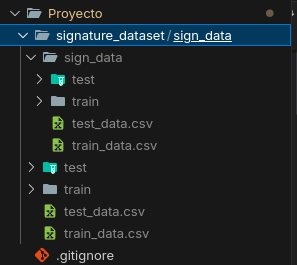

In [ ]:
# Download latest version ()
# Descarga del dataset desde Kaggle, dado en la misma página del dataset, este es el dataset de entrenamiento, validación y test del modelo.
path = kagglehub.dataset_download("robinreni/signature-verification-dataset")
print("Path to dataset files:", path)

# Definimos el destino donde se moverá la carpeta descomprimida
destino = os.path.join(os.getcwd(), "signature_dataset")
#movemos la carpeta a la par que todo lo demás
if not os.path.exists(destino):
    shutil.copytree(path, destino, dirs_exist_ok=True)
    print("Directorio movido con éxito :)")
else:
    print("Directorio ya existente, no es necesario mover de nuevo :)")

# Eliminación de carpeta duplicada "sign_data/sign_data/" si es que se genera al descromprimir
CARPETA_PRINCIPAL = "signature_dataset/sign_data/"
CARPETA_DUPLICADA = "sign_data"

ruta_duplicada = os.path.join(CARPETA_PRINCIPAL, CARPETA_DUPLICADA)
    
print(f"Ruta raíz: {CARPETA_PRINCIPAL}")
print(f"Ruta repetida a verificar: {ruta_duplicada}")
    
if not os.path.exists(ruta_duplicada) or not os.path.isdir(ruta_duplicada):
    print("Directorio repetido no encontrado o ya corregido :)")
else:
    shutil.rmtree(ruta_duplicada)
    print("Directorio repetido eliminado.")

In [ ]:
#NOTA: ESTE DATASET SOLO SE OCUPA PARA VERIFICAR EL MODELO. EJECUTAR UNA SOLA VEZ ESTA CELDA. 
#SOLO EJECUTAR SI SE VA A PROBAR EL MODELO ENTRENADO, ESTE ES UN DATASET DIFERENTE.
path = kagglehub.dataset_download("akashgundu/signature-verification-dataset")
print("Path to dataset files:", path)
# Definimos el destino donde se moverá la carpeta descomprimida
destino = os.path.join(os.getcwd(), "Dataset_verificador")
#movemos la carpeta a la par que todo lo demás
if not os.path.exists(destino):
    shutil.copytree(path, destino, dirs_exist_ok=True)
    print("Directorio movido con éxito :)")
else:
    print("Directorio ya existente, no es necesario mover de nuevo :)")

## Problema: ¡Dataset sin validación!
Cuando descargamos el dataset ahora teníamos un nuevo problema y es que este dataset no tenía conjunto de validación.
Como vimos en clase y durante los laboratorios, el tener un conjunto de validación sirve demasiado para ver que el modelo no se subreajuste o haga cosas raras y vaya bien encaminado. Es por eso que teníamos que obtenerlo de alguna forma del mismo dataset.
- En primera instancia se nos ocurrió partir manualmente las carpetas que venían en train, sonaría lógico pero teníamos otro problema. Y es que el dataset tenía muchísimas relaciones con otras imagenes entonces no podíamos tomar las carpetas de imagenes así nada más.
- Luego se nos ocurrió tomar un 20% del csv de train para nuestra validación, pero esto provocaba otro fallo y es que partirlo con sklearn toma de forma indiscriminada este 20% por lo que habría relaciones en las imagenes que se ejecutan tanto en train como en la validación lo que sería como hacer trampa, el modelo vería imagenes de un sujeto A y posteriormente en la validación podría volver a ver estas imagenes del sujeto A pero con otra imagen secundaria distinta, lo cual no es correcto y produce fugas de información y falsos sesgos en el modelo.
- Finalmente se nos ocurrió la solución a nuestro problema de validación:

### Estructura del csv.

En el csv tenemos la siguiente estructura:

001/001_04.PNG,001_forg/0119001_03.png,1

001/001_09.PNG,001/001_23.PNG,0

Donde se tiene primero una imagenA y una imagen B, como se puede observar y deducir, la carpeta forg es para firmas falsas de un mismo individuo. La etiqueta 1 indica que las firmas son distintas y que no tienen nada que ver, es decir, son falsas. Mientras que la etiqueta 0 indica que las firmas son de la misma persona, es decir, son genuinaas.

Ahora, el dataset (afortunadamente) está ordenado sistemáticamente por bloques de relaciones de individuos, es decir, primero van las relaciones falsas y genuinas de una misma persona, después de ese bloque completo, no vuelve a aparecer.
Por lo que decidimos solo cortar el dataset de train pero no de forma aleatoria, sino tomando bloques completos para hacer que el csv de validación sea completamente disjunto del nuevo conjunto de train. 
Por ejemplo, si train se compone de los bloques del 1 al 15, partimos el dataset original en un 20% y solo recuperarmos $\pm$ de lo que pudo haberle faltado a ese bloque. 
Si por ejemplo al partir tomamos un pedazo del bloque del individuo 6, entonces recuperamos lo que se puede llegar a quedar en el dataframe de train.

Como el dataframe ya apunta hacia la carpeta de train con las imagenes, no importa realmente esto último ya que los datos de validación aunque hagan referencia a esta carpeta, solo se usarán cuando necesitemos el conjunto de validación.

Con esto solucionamos el problema de no tener un conjunto de validación para nuestro modelo.


In [ ]:
#Primero definimos las rutas que vamos a ocupar, el entrenamiento,test tanto para imagenes como para csv
# Path(__file__).resolve().parent obtiene la ruta absoluta del script que se ejecuta
# Path('signature_dataset/sign_data') le añade la ruta relativa a los datos que vamos a estar usadno.

DIRECTORIO_BASE = Path(os.getcwd()) #Ruta de nuestro proyecto :)
RUTA_DATOS = DIRECTORIO_BASE / 'signature_dataset' / 'sign_data' #Ruta principal

#Ruta de los csv de entrenamiento y test
ruta_train_original_csv = RUTA_DATOS / 'train_data_original.csv'
ruta_train_csv = RUTA_DATOS / 'train_data.csv'
ruta_test_csv = RUTA_DATOS / 'test_data.csv'
ruta_val_csv = RUTA_DATOS / 'val_data.csv'

#Ruta de entrenamiento y test
ruta_train = RUTA_DATOS / 'train'
ruta_test = RUTA_DATOS / 'test'

#Ruta de imagen de prueba
ruta_imagen_train = RUTA_DATOS / 'train/001/001_01.PNG'
print(f"Ruta de prueba; entrenamiento csv: {ruta_train_csv}")

# Si ya habíamos divido antes los datos, no es necesario hacerlo de nuevo
if os.path.isfile(ruta_train_original_csv):
    print("Archivo de entrenamiento original ya existe. No es necesario dividir de nuevo.")
else:
    train = pd.read_csv(ruta_train_csv, header=None, names=['imagen1', 'imagen2', 'etiqueta'])
    train['grupo'] = train['imagen1'].apply(lambda x: x.split('/')[0]) 

    grupos_imagenes = [g for _, g in train.groupby('grupo')]
    train_grupos = []
    val_grupos = []

    tamaño_train_original = len(train)
    tamaño_val_esperado = tamaño_train_original * 0.2
    actual = 0
    for grupo in grupos_imagenes:
        if actual < tamaño_val_esperado:
            val_grupos.append(grupo)
            actual += len(grupo)
        else:
            train_grupos.append(grupo)

    #Reseteo de indices y eliminación del grupo
    df_train = pd.concat(train_grupos).reset_index(drop=True)
    df_val = pd.concat(val_grupos).reset_index(drop=True)
    df_train = df_train.drop(columns=['grupo'])
    df_val = df_val.drop(columns=['grupo'])


    #Guardado del csv original
    train.to_csv(os.path.join(RUTA_DATOS, 'train_data_original.csv'), index=False, header=False)

    #Guardado del csv de validación y entrenamiento
    df_train.to_csv(os.path.join(RUTA_DATOS, 'train_data.csv'), index=False, header=False)
    df_val.to_csv(os.path.join(RUTA_DATOS, 'val_data.csv'), index=False, header=False)

#Lectura de los nuevos datasets
nombres_columnas = ['imagen1', 'imagen2', 'etiqueta']
df_train = pd.read_csv(ruta_train_csv, names = nombres_columnas)
df_test = pd.read_csv(ruta_test_csv, names = nombres_columnas)
df_val = pd.read_csv(ruta_val_csv, names = nombres_columnas)

img_train = Image.open(ruta_imagen_train)
#Primeros datos de df_train
print(df_train.tail())

#Vemos el tamaño para comprobar que se ha reducido entre test y validación
print(len(df_train), len(df_val), len(df_test))

img_train

## Obtener datos de nuestros dataframes
Con los problemas anteriormente solucionados ahora tenemos que cargar las imagenes y etiquetas de nuestros csv para que posteriormente podamos usarlos en el entrenamiento y validación de nuestro modelo.

Para ello, creamos la clase de SignatureDataset la cual hace uso de dataset la cual torch tiene como una clase abstracta para los datasets con métodos comunes para obtener, inicializar u obtener logintud de los datos.
Con esta clase, podemos abrir las imagenes y etiquetas de cualquiera de nuestros dataframes de validación, entrenamiento y testeo. 

In [ ]:
class SignatureDataset(Dataset):
    """
    Clase para cargar el dataset de forma correcta. Utiliza Dataset que es la forma para cargar
    datasets como los pide torch.
    """
    def __init__(self, datos, ruta, transform = None):
        """Función para inicializar los datos con lo que vamos a trabajar.

        Args:
            datos(dataframe): datos del csv correspondiente a train, val o test leídos como un dataframe(df) de pandas
            ruta(path): ruta donde está el csv de los datos a trabajar
            transform(transform): transformaciones a los objetos con los que vamos a trabajar
        """
        self.datos = datos
        self.ruta = ruta
        self.transform = transform
    
    def __len__(self):
        """Longitud del dataframe con el que trabajamos
        """
        return len(self.datos)
    
    def __getitem__(self, indice):
        """Función para obtener las imagenes correspondientes al indice en el dataframe.

        Args:
            indice(int): indice en el dataframe a obtener las imagenes y etiqueta (0 o 1)

        Returns:
            Imagenes transformadas junto con su etiqueta como un tensor de torch
        """
        imagen1 = Image.open(self.ruta / self.datos["imagen1"][indice])
        imagen2 = Image.open(self.ruta / self.datos["imagen2"][indice])
        etiqueta = self.datos["etiqueta"][indice]

        if self.transform:
            imagen1 = self.transform(imagen1)
            imagen2 = self.transform(imagen2)
        
        #Regresamos las imagenes transformadas junto con su etiqueta. 
        #La etiqueta está casteada a float, ya que torch trabaja con floats
        #(principalmente evitamos errores de cálculo) aunque sean 0's y 1's, mejor prevenir :)
        return imagen1, imagen2, torch.tensor(etiqueta, dtype=torch.float32)

Los siguientes pasos fueron inspirados del siguiente paper, en donde para un problema de firmas, investigadores usaron redes neuronales con distintos datasets para probar su red.

https://arxiv.org/pdf/1707.02131

Sin embargo, su trabajo creaba la red neuronal desde 0. Nosotras buscabamos algo más sencillo pero igual de potente. En este se utilizan redes siamesas, aunque no las vimos en el curso las investigamos para ver por qué eran elegidas en el artículo, vimos que son ampliamente utilizadas junto con redes triplets para problemas de biometría. 



Principalmente de aquí tomamos las ideas de las capas que ibamos a utilizar así como un buen indicio de los hiperparámetros que podíamos llegar a utilizar.

A nosotras se nos ocurrió que utilizar DataAugmentation para variar las imagenes era una buena estrategia para darle aún más variedad al modelo a la hora de entrena y asegurar que el modelo pudiera realmente aprender cuando se hiciera el entrenamiento.

In [ ]:
#El tamaño de reescalamiento lo consideramos tanto la potencia como las caraterísiticas de las firmas
#Las firmas no son simpre cuadradas, por eso escogimos algo estándard el cual es rectangular
tamaño = (128,256)

#Data Augmentation
trans_train = transforms.Compose([
     #Transformación de tamaño, rotación y tamaño. Cada que se mande un Dataloader, tendrá ligeras variaciones
     transforms.Resize(tamaño),
     transforms.RandomRotation(5),
     transforms.RandomResizedCrop(tamaño, scale=(0.9, 1.1)),
     transforms.ToTensor()])

trans_test_val = transforms.Compose([transforms.Resize(tamaño), transforms.ToTensor()])


#Cada uno cargando correctamente con su respectivo dataframe transformado
#En particular, para el entrenamiento transformamos un poco la imagen para tener ligeras variaciones,
#y que el modelo aprenda a generalizar mejor. En la validación y test se conservan de igual forma.
train_dataset = SignatureDataset(df_train, ruta_train, transform= trans_train)
test_dataset = SignatureDataset(df_test, ruta_test, transform= trans_test_val)
val_dataset = SignatureDataset(df_val, ruta_train, transform= trans_test_val)

In [ ]:
#Aquí solo verificamos que las imagenes se estén cargando correctamente
#Esta parte nos ayudó un LLM para graficar dos imagenes juntas en pyplot
def imagenes_pares(imagen1, imagen2, etiqueta):
    fig, axes = plt.subplots(1,2)
    axes[0].imshow(np.transpose(imagen1.numpy(), (1, 2, 0)))
    axes[1].imshow(np.transpose(imagen2.numpy(), (1, 2, 0)))

imagen1, imagen2, etiqueta = val_dataset[120]
imagenes_pares(imagen1, imagen2, etiqueta)

## Definción de la red neuronal

Como mencionamos anteriormente, el paper nos dio un buen acercamiento. Pero tal vez podríamos recurrir a otras opciones y viendo un poco el panorama (y con el fine tuning que se nos permitió) decidimos usar parte de un modelo pre-entrenado el cual fue una RestNet la cual nos sirve principalmente para tener texturas y reconocimientos como ya definidos y que el aprendizaje del modelo pueda ser muchisimo más sencilla. Quitamos la ultima capa ya que la que tiene por defecto no nos sirve y tenemos que usar una que soporte las dimesiones e incrustaciones (embeddings) de nuestra imgen de 128 X 256.

En estos artículos es más claro como se puede adapatar un modelo pre-entrenado para ocuparlo en nuestro propios modelos. En estos casos se ocuparon para datasets de 10 clases, pero nosotras simplemente la ocupamos para firmas falsas y verdaderas.

- https://www.kaggle.com/code/ggsri123/implementing-resnet18-for-image-classification
- http://medium.com/@staytechrich/custom-deep-learning-model-with-a-resnet18-backbone-for-cifar-10-image-classification-4f844647e130

In [ ]:
class SiamesCNN_RN18(nn.Module):
    def __init__(self):
        super(SiamesCNN_RN18, self).__init__()
        
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        #Capa final de nuestro modelo, sustituyendo la capa final del modelo de resnet18 preentrenado
        #Embedding para extraer características, completamente conectada
        self.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            #regularización con dropout
            nn.Dropout(0.5), 
            
            nn.Linear(512, 256),
            nn.ReLU(),
            
            #Salida con embedding de 128 dimensiones
            nn.Linear(256, 128)
        )
    
    #Es importante notar que el modelo preeentrando ya tiene capas convolucionales
    #Entre ellas aplanado de las imagenes, conversiones a tensores 
    def forward_once(self, out):
        out = self.backbone(out)
        out = self.fc(out)
        out = out / out.norm(p=2, dim=1, keepdim=True) # Normalización L2 para la función de pérdida
        return out 
        
    def forward(self, img1, img2):
        y1 = self.forward_once(img1)
        y2 = self.forward_once(img2)
        return y1, y2

# Función de Pérdida

Para las funciones de pérdida se sigue del mismo artículo en donde aplican ContrastiveLoss. Al investigar acerca de esta función y en términos muy sencillos mide la similitud de dos objetos en donde vemos la similitud de sus embeddings.

Para los pares positivos como el los vistos durante *test_data.csv*, aquellos con etiquetado similar (0) representan pares similares, por lo que queremos que sus embeddings sean más cercanos unos de otros. Mientras que si son de una clase diferente (1) entonces son muy diferentes por lo que queremos que sus embeddings sean distintos de otros.

La función comunmente usada para el contrastiveLoss es la siguiente:

$$L = y \cdot D^2 + (1-y) \cdot max(0,m - D)^2$$

- $y$ es la etiqueta, 0 o 1 si son pares diferentes o iguales
- $D$ es la distancia euclideana $D = ||f(x_1) - f(x_2)||_2$
- $m$ es el márgen mínimo de separación

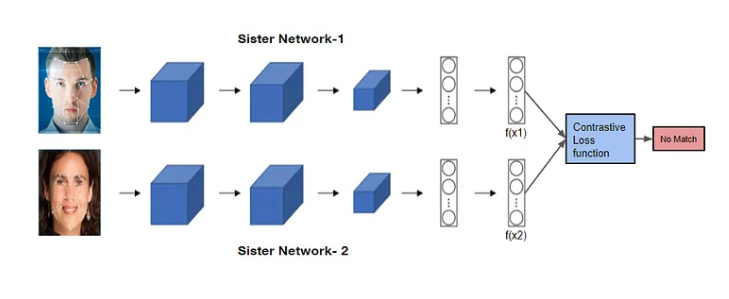

Por la naturaleza del problema y el dataset otorgado con su respectivo .csv, se optó por usar esta función de pérdida. 

Aunque existe la opción de usar la entropía cruzada binaria, para dos clases investigando un poco al ser datos _biometricos_ muchas veces es mejor.

https://gowrishankar.info/blog/introduction-to-contrastive-loss-similarity-metric-as-an-objective-function/

In [ ]:
class ContrastiveLoss(nn.Module):
    """Función de pérdida de nuestra red neuronal. Si el par tiene etiqueta 0,
    tratamos de acercar esta distancia porque son similares. Si el par es 1, alejamos esta distancia porque son falsas
    """
    def __init__(self, margen=1.0):
        super(ContrastiveLoss, self).__init__()
        #Este es nuestro margen para poner un tope entre falsas y reales.
        self.margen = margen
    
    def forward(self, output1, output2, etiqueta):
        """En el caso de esta función se mide la similitud entre dos pares de imagenes,
        es por eso que se ocupa la distancia euclidiana de ambas. 
        output1 y output2 son las respectivas imagenes con pares y sus etiquetas
        Usamos torch para las operaciones matemáticas al trabajar con tensores."""
        
        # Distancia euclideanda, es D en la fórmula        
        distancia_euclideana = nn.functional.pairwise_distance(output1, output2)
        #Función de pérdida
        contrastive_f = torch.mean((1 - etiqueta) * torch.pow(distancia_euclideana, 2) + (etiqueta) * torch.pow(torch.clamp(self.margen - distancia_euclideana, min=0.0), 2))
        
        return contrastive_f

In [ ]:
#Seleccionamos el modelo y la función de pérdida
modelo = SiamesCNN_RN18()
f_perdida = ContrastiveLoss()

In [ ]:
# Usamos ya sea el CPU o GPU dependiendo de la computadora
if torch.cuda.is_available():
    modelo = modelo.cuda()
print(f"Equipos seleccionado: {'GPU' if torch.cuda.is_available() else 'CPU'}")

## Hiperparámetros

Para los hiperparámetros de nuestro modelos decidimos usar los siguientes:
### Optimizador
Para el optimizador decidimos usar SDG pero en su variante con momentum, en este caso para conservar aprendizajes anteriores para los siguientes. Pensamos que en el caso de las firmas, esto podría ser muy útil.
En este caso, tenemos tambien que elegir un momentum y un decaimiento de los pesos, para el momentum inicial escogimos 0.9 y para el decimiento 1e-3.

### Epocas
Para las épocas decidimos un total de 20 de entrada, sin embargo, para esto también utilizaremos early-stopping como vimos en el curso para evitar overfitting en nuestro modelo con 6 iteraciones de tolerancia si no hay mucha mejora.

### Batch
Para el tamaño del bath, decidimos usar entre 32 y 16 debido al poder de nuestras computadoras. Usaremos 32 si tenemos la opotunidad de tener una GPU (la pudimos conseguir) pero para fines de cualquier computadora lo dejaremos en 16.

### Taza de aprendizaje
En la taza de aprendizaje optamos por un valor de entrada muy común el cual es de 1e-4 para experimentar las primeras veces.

In [ ]:

# Hiperparámetros
batch = 32
epocas = 20
early_stopping = 6
taza_aprendizaje = 1e-4
decaimiento = 1e-3
momentum=0.9

#optimizador de nuestra red
optimizador = optim.SGD(modelo.parameters(), taza_aprendizaje, momentum, weight_decay=decaimiento)
#Carga de datos de del entrenamiento y test
#Solo hacemos shuffle en el train, los demás pueden permanecer sin ser aleatorios
dataLoader_train = DataLoader(train_dataset, batch_size=batch, shuffle=True)
dataLoader_test = DataLoader(test_dataset, batch_size=batch, shuffle=False)
dataLoader_val = DataLoader(val_dataset, batch_size=batch, shuffle=False)

In [ ]:
def train(modelo, f_perdida, optimizador, dataLoader_train, dataLoader_val, epocas=20, early_stopping=6):

    mejor_loss_val = float('inf')
    contador_early_stopping = 0

    #Iteramos durante las épocas definidas en el entrenamiento
    for epoca in range(epocas):
        modelo.train()
        perdida_total = 0.0
        #Para cada una de los datos en el csv se realiza el entrenamiento con el par de imagenes
        for img1, img2, etiqueta in tqdm.tqdm(dataLoader_train):
            if torch.cuda.is_available():
                #En caso de tener una gpu, lo que hacemos es calcular todo directamente con la gpu
                img1, img2, etiqueta = img1.cuda(), img2.cuda(), etiqueta.cuda()

            #Hacemos uso del optimizador y la función de pérdida.
            optimizador.zero_grad()
            salida1, salida2 = modelo(img1, img2)
            perdida = f_perdida(salida1, salida2, etiqueta.float())
            #Propagamos el gradiente a las demás capas
            perdida.backward()
            optimizador.step()

            perdida_total += perdida.item()
        #Pérdida promedio por época
        perdida_train = perdida_total / len(dataLoader_train)

        #Hacemos la validación del modelo con los datos de validación, ambos son disjuntos.
        modelo.eval()
        perdida_val = 0.0
        with torch.no_grad():
            batch_idx = 0 # Contador auxiliar
            for img1, img2, etiqueta in dataLoader_val:
                if torch.cuda.is_available():
                    #Mismo proceso que en el entrenamiento con cuda
                    img1, img2, etiqueta = img1.cuda(), img2.cuda(), etiqueta.cuda()

                #Se realiza la evaluación del modelo
                salida1, salida2 = modelo(img1, img2)
                perdida = f_perdida(salida1, salida2, etiqueta.float())
                perdida_val += perdida.item()

        perdida_val /= len(dataLoader_val)

        #Early Stopping si el modelo empieza a hacer overfitting
        if perdida_val < mejor_loss_val:
            mejor_loss_val = perdida_val
            contador_early_stopping = 0
            #Guardamos el modelo antes de que el early stopping se active, es decir, la "paciencia"
            #se agota y no hay mejora en las iteraciones
            torch.save(modelo.state_dict(), 'mejor_modelo_entrenado.pt')
        else:
            contador_early_stopping += 1
        
        #Para tener presente lo que pasa, imprimimos cómo van las épocas en las que entrena nuestro modelo
        #Esto para confirmar durante el entrenamiento que todo va bien.
        print(f"Época {epoca+1} \nTrain Loss: {perdida_train:.4f} \nVal Loss: {perdida_val:.4f} \nCont Early Stop: {contador_early_stopping}")
        
        if contador_early_stopping >= early_stopping:
            print("No hay más mejora en las iteraciones")
            break

In [ ]:
#Entrenamiento
#NOTA: EVITAR CORRER SI NO SE TIENE LA GPU
train(modelo, f_perdida, optimizador, dataLoader_train, dataLoader_val, epocas, early_stopping)

In [ ]:
#Carga del modelo entrenado dependiendo si se tiene GPU o no
dispositivo_eval = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo para correr el mode: {dispositivo_eval}")
#Instanciamos nuestro modelo y cargamos sus pesos
modelo_eval = SiamesCNN_RN18()
try:
    estado_modelo_eval = torch.load('mejor_modelo_entrenado.pt', map_location=dispositivo_eval, weights_only=True)
    modelo_eval.load_state_dict(estado_modelo_eval)
    modelo_eval.to(dispositivo_eval)
    modelo_eval.eval()
    print("Modelo cargado exitosamente")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")


## Evaluación del modelo

Finalmente evaluamos el modelo con métricas simples, en donde se evalúa con test y vemos el desempeño de cuantos realmente son falsos y cuantos verdaderos y si es que puede acertar estos correctamente.

In [ ]:
def metricas(modelo, dataLoader_test, umbral_distancia=0.3):
    #modelo.eval descativa los dropouts del modelo original, aunque ya lo desactivamos antes, nunca está de más
    modelo.eval()
    #Arreglos para guardar predicciones del modelo
    y_verdadero = []
    y_predicho = []

    #Hacemos las predicciones sobre todo el dataset de test
    #El paso es similar a como se vio durante el entrenamiento para la validación
    with torch.no_grad():
        for img1, img2, etiqueta in tqdm.tqdm(dataLoader_test):
            if torch.cuda.is_available():
                img1, img2, etiqueta = img1.cuda(), img2.cuda(), etiqueta.cuda()

            salida1, salida2 = modelo(img1, img2)
            distancia_euclidiana = torch.pairwise_distance(salida1, salida2)
            prediccion = (distancia_euclidiana > umbral_distancia).int() 
            #Las evaluaciones de sklearn funcionan con numpy, por lo que sí o sí tenemos que pasar esto a CPU independientemente 
            #de si se tiene o no una GPU porque si no suelta error.
            y_verdadero.extend(etiqueta.cpu().numpy())
            y_predicho.extend(prediccion.cpu().numpy())
    
    #Predicciones de nuestro modelo de ciertos y falsos
    y_verdadero = np.array(y_verdadero)
    y_predicho = np.array(y_predicho)

    #Imprimos las métricas dado el resultado del dataset de evaluación
    metricas = {
        'Accuracy': accuracy_score(y_verdadero, y_predicho),
        'Precision': precision_score(y_verdadero, y_predicho),
        'Recall': recall_score(y_verdadero, y_predicho),
        'F1-Score': f1_score(y_verdadero, y_predicho),
    }

    return metricas

In [ ]:
#llamado de la función de métricas para evaluar el modelo
#NOTA: EVITAR CORRER SI NO SE TIENE LA GPU
metricas(modelo_eval, dataLoader_test)

# Pruebas finales
Finalmente, con el dataset que descargamos extra el cual no se uso ni para entrenamiento ni para nada anteriormente, serán nuestras imagenes las cuales pueden probar si en efecto nuestro modelo es correcto o todo fue un engaño estrepitoso ):

## Problema: Metricas insuperables

Antes de entrar a esta parte, durante la evaluación del modelo tuvimos algo que nos empezó a trabar mucho durante la evaluación del modelo y tuvimos que recurrir a modelos como Gemini y GPT para ver si encontraban el error. Al evaluar el modelo, agregaramos lo que agregaramos para "mejorar" nuestro modelo, al evaluar no podía superar una barrera del F1-Score del 0.68% y más raro aún, el recall simpre estaba en 1 y lo demás parecía un monedazo. 

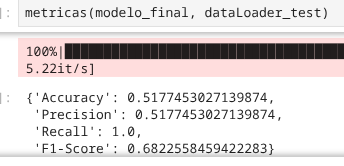
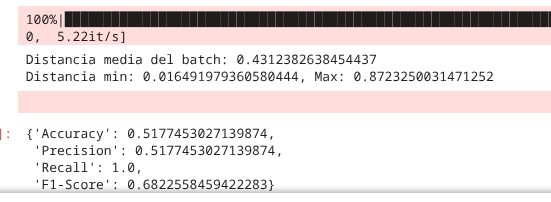

Agregaramos distintas cosas o cambiando los hiperparámetros, el problema persistia y parecía que no tenía solución por lo que pedimos que revisaran partes importantes de nuestro código como el entrenamiento, la definición de la red y la función de pérdida pero ninguna LLM podía encontrar por qué no se podía superar esta barrera del 0.68%.

Nos sugerían cosas como implementar una red Triplet, definir una red convolucional desde 0, usar scheduling, batch dinámico, k-neighbors durante el paso del dataset, incluso usar un modo muy raro de torch para tener debugs y logs durante todo el entrenamiento entre otras cosas. Algunas las probamos para ver si el error se encontraba en alguna de todas estas sugerencias que nos daban los LLMs, pero parecía no solucionarse el error.

*Spoiler: Nada de eso era el error, nuestra red estaba bien definida.*

El error para que el F1-score saliera tan bajo es que teníamos la siguiente linea en nuestro código durante la evaluación:

```
prediccion = (distancia_euclidiana < umbral_distancia).int()
```

Después de una revisión exhaustiva nos dimos cuenta que esto invertia completamente los resultados de las predicciones del modelo. Las predicciones las marcaba mal y al revés. Tal vez se nos pasó por un error al presionar no presionar shift con la tecla de los mayores o menores jajaj
Pero cambiando esa linea:

```
prediccion = (distancia_euclidiana > umbral_distancia).int()
```

El score de nuestro modelo era ya correcto y el que verdaramente teníamos que haber tenido. En retrospectiva, todo se murió por no presionar bien una tecla ):

In [ ]:
#Carga del modelo entrenado dependiendo si se tiene GPU o no
#Instanciamos nuestro modelo y cargamos sus pesos
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo para correr el mode: {dispositivo}")
modelo_produccion = SiamesCNN_RN18()
try:
    estado_modelo = torch.load('mejor_modelo_entrenado.pt', map_location=dispositivo, weights_only=True)
    modelo_produccion.load_state_dict(estado_modelo)
    modelo_produccion.to(dispositivo)
    modelo_produccion.eval()
    print("Modelo cargado exitosamente :)")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")


In [ ]:
def probar_firmas(modelo, ruta_img1, ruta_img2, umbral=0.15):
    """
    Función para probar el modelo entrenado con dos firmas que nunca haya visto
    Args:
        modelo(model): modelo entrenado durante el notebook
        ruta_img1(imagen): 
        ruta_img2(imagen): 
        umbral(float):
    Returns:
        Resultado si las firmas puestas son genuinas o si son falsas.
    """
    #Reescala que usamos para el modelo (Esto es importante, porque si reescalamos de otra forma, puede que el modelo no lo reconozca bien)
    tamaño = (128, 256) 
    reescala = transforms.Compose([transforms.Resize(tamaño), transforms.ToTensor()])
    
    #Intentamos cargar las imagenes si todo sale bien
    try:
        #Si son png o jpg o cualquier tipo las "convertimos" a 3 canales para evitar el canal alpha de transparencia y evitamos errores
        img1_pil = Image.open(ruta_img1).convert("RGB") 
        img2_pil = Image.open(ruta_img2).convert("RGB")
    except Exception as e:
        print(f"Error al cargar las imágenes: {e}")
        return
    
    #Unsqueeze se ocupa ya que ya no tenemos el batch de 32 imagenes, ahora lo que hacemos
    #es pasar solo 2. En vista de un tensor ya no es de 32 como podría ser cuando entrenamos sino que es de 2 porque solo le pasamos dos imagenes
    #sino, el modelo nos diría como "incompleto, me faltan otras 30"
    img1_t = reescala(img1_pil).unsqueeze(0)
    img2_t = reescala(img2_pil).unsqueeze(0)

    device = torch.device(dispositivo if torch.cuda.is_available() else "cpu")
    modelo.to(device)
    modelo.eval() # Modo evaluación (apaga Dropout)
    img1_t = img1_t.to(device)
    img2_t = img2_t.to(device)
    
    #Precedimos, casi este paso de with se repite durante las evaluaciones, test y predicciones (muy importante)
    #No utilizamos el for debido a que como dijimos anteriormente, solo tenemos dos imagenes
    with torch.no_grad():
        salida1, salida2 = modelo(img1_t, img2_t)
        distancia_imagenes = torch.nn.functional.pairwise_distance(salida1, salida2)
        distancia_valor = distancia_imagenes.item()
    
    #Para esto se ocupa el umbral (mismo que nos da los mejores resultados en la evaluación) 
    #y por lo tanto los mejores para las predicciones de cualqueir par de firmas
    #Si la distancia < 0.3 entonces la firma es genuina
    #Si la distancia > 0.3 entonces la firma es posiblemente falsa
    es_firma_misma_persona = distancia_valor < umbral
    resultado_texto = "Firmas genuinas :)" if es_firma_misma_persona else "Firma falsa, posible fraude ):"
    color_texto = 'green' if es_firma_misma_persona else 'red'

    #Confirguramos al plot para tener dos imagenes y su tamaño
    fig, axes = plt.subplots(1, 2, figsize=(5, 2))
    
    axes[0].imshow(img1_pil)
    axes[0].set_title("Firma 1")
    axes[0].axis('off')

    axes[1].imshow(img2_pil)
    axes[1].set_title("Firma 2")
    axes[1].axis('off')

    #Mostramos nuestos resultados en el plot
    plt.suptitle(f"Resultado: {resultado_texto}\nDistancia: {distancia_valor:.4f} (Umbral: {umbral})", color=color_texto, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

#Ruta principal de pruebas finales
#Para hacer esto pueden descargar el dataset de prueba que es la segunda celda. Solo se corre una vez y ven cual ruta agregar
#rutas sin forge -> originales de una persona
#rutas con forge -> firmas falsas
RUTA_DATOS_PF = DIRECTORIO_BASE / 'Dataset_verificador' / 'extract' 
ruta_a = RUTA_DATOS_PF / '001/1-001_01.jpg'
ruta_b = RUTA_DATOS_PF / '001/1-001_02.jpg'
ruta_falsa = RUTA_DATOS_PF / '001_forg/1-002_010.jpg'


probar_firmas(modelo, ruta_a, ruta_b, umbral=0.3)
#probar_firmas(modelo, ruta_a, ruta_falsa, umbral=0.3)